# CDS-aware manipulations — model comparison

Compare SpliceAI and SpliceMamba on the **same 1,497 protein-coding chr1/3/5/7/9 genes** (subset that passes ATG + mod-3 CDS validation against GENCODE V24-lift37) under five conditions:

| dataset | what it is |
|---|---|
| `filtered_baseline` | original sequences, only valid-CDS genes (apples-to-apples baseline) |
| `nt_shuffle` | every CDS nucleotide permuted; UTRs untouched |
| `codon_shuffle` | CDS codons permuted in the actual reading frame; UTRs untouched |
| `remove1` | 1 random CDS position deleted **per gene** (per CDS, not per exon); UTRs untouched |
| `remove2` | 2 random CDS positions deleted per gene; UTRs untouched |

Each manipulation gets its own datafile + dataset; all evaluations run with the same model checkpoints (SpliceMamba `checkpoints/best.pt`, SpliceAI 5-model ensemble from the `spliceai` PyPI package).

Excluded genes (155 of 1,652; logged in `data/cds_invalid_log.json`):
* 1,121 with no GENCODE V24 transcript match (lncRNAs, antisense, very recent name changes)
* 118 with CDS spanning positions outside the datafile's exons
* 17 whose CDS doesn't start with ATG
* 19 whose CDS length isn't divisible by 3
* 1 with a CDS shorter than 3 bp

In [1]:
from __future__ import annotations
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('..').resolve()
RESULTS_ROOT = REPO_ROOT / 'evaluation' / 'results'

MODES = ['filtered_baseline', 'nt_shuffle', 'codon_shuffle', 'remove1', 'remove2']
MODELS = ['splicemamba', 'spliceai']
RESULT_DIRS = {
    'filtered_baseline': RESULTS_ROOT / 'cds_baseline',
    'nt_shuffle':        RESULTS_ROOT / 'cds_nt_shuffle',
    'codon_shuffle':     RESULTS_ROOT / 'cds_codon_shuffle',
    'remove1':           RESULTS_ROOT / 'cds_remove1',
    'remove2':           RESULTS_ROOT / 'cds_remove2',
}

# Status check
for mode, d in RESULT_DIRS.items():
    sm = (d / 'splicemamba_results.json').exists()
    sa = (d / 'spliceai_results.json').exists()
    print(f'  {mode:18s}  splicemamba={"OK" if sm else "MISSING"}   spliceai={"OK" if sa else "MISSING"}   ({d})')

  filtered_baseline   splicemamba=OK   spliceai=OK   (/mnt/lareaulab/mparsa/splicing/evaluation/results/cds_baseline)
  nt_shuffle          splicemamba=OK   spliceai=OK   (/mnt/lareaulab/mparsa/splicing/evaluation/results/cds_nt_shuffle)
  codon_shuffle       splicemamba=OK   spliceai=OK   (/mnt/lareaulab/mparsa/splicing/evaluation/results/cds_codon_shuffle)
  remove1             splicemamba=OK   spliceai=OK   (/mnt/lareaulab/mparsa/splicing/evaluation/results/cds_remove1)
  remove2             splicemamba=OK   spliceai=OK   (/mnt/lareaulab/mparsa/splicing/evaluation/results/cds_remove2)


In [2]:
def load_metrics(model: str, mode: str) -> dict | None:
    p = RESULT_DIRS[mode] / f'{model}_results.json'
    if not p.exists():
        return None
    return json.loads(p.read_text())['metrics']

RESULTS = {(m, k): load_metrics(m, k) for m in MODELS for k in MODES}
loaded = sum(1 for v in RESULTS.values() if v is not None)
print(f'Loaded {loaded}/{len(RESULTS)} result files')

Loaded 10/10 result files


## Headline AUPRC table

Mean AUPRC = average of per-class donor and acceptor AUPRC.

In [3]:
rows = []
for mode in MODES:
    for model in MODELS:
        m = RESULTS.get((model, mode))
        if not m:
            rows.append({'manipulation': mode, 'model': model, 'auprc': None,
                         'auprc_donor': None, 'auprc_acceptor': None,
                         'topk': None, 'f1': None})
            continue
        rows.append({
            'manipulation': mode,
            'model': model,
            'auprc': m['auprc']['auprc_mean'],
            'auprc_donor': m['auprc']['auprc_donor'],
            'auprc_acceptor': m['auprc']['auprc_acceptor'],
            'topk': m['topk']['topk_global_mean'],
            'f1': (m['f1_optimal']['f1_donor_best'] + m['f1_optimal']['f1_acceptor_best']) / 2,
        })
df = pd.DataFrame(rows)
df.style.format({'auprc': '{:.4f}', 'auprc_donor': '{:.4f}', 'auprc_acceptor': '{:.4f}',
                 'topk': '{:.4f}', 'f1': '{:.4f}'}, na_rep='—')

,manipulation,model,auprc,auprc_donor,auprc_acceptor,topk,f1
0,filtered_baseline,splicemamba,0.9707,0.9731,0.9682,0.9294,0.9296
1,filtered_baseline,spliceai,0.9695,0.9721,0.9669,0.9233,0.9238
2,nt_shuffle,splicemamba,0.4792,0.3501,0.6084,0.5005,0.5061
3,nt_shuffle,spliceai,0.4710,0.3417,0.6003,0.4831,0.4946
4,codon_shuffle,splicemamba,0.6847,0.5646,0.8048,0.6597,0.6658
5,codon_shuffle,spliceai,0.6072,0.4822,0.7323,0.5955,0.6063
6,remove1,splicemamba,0.9684,0.9718,0.9650,0.9269,0.9273
7,remove1,spliceai,0.9677,0.9712,0.9642,0.9212,0.9216
8,remove2,splicemamba,0.9665,0.9701,0.9629,0.9240,0.9242
9,remove2,spliceai,0.9661,0.9699,0.9624,0.9192,0.9197


## AUPRC bar chart, grouped by manipulation

Bars sit side-by-side per manipulation. The dashed line is the corresponding model's `filtered_baseline` AUPRC, so any drop is the manipulation's effect on the same gene set.

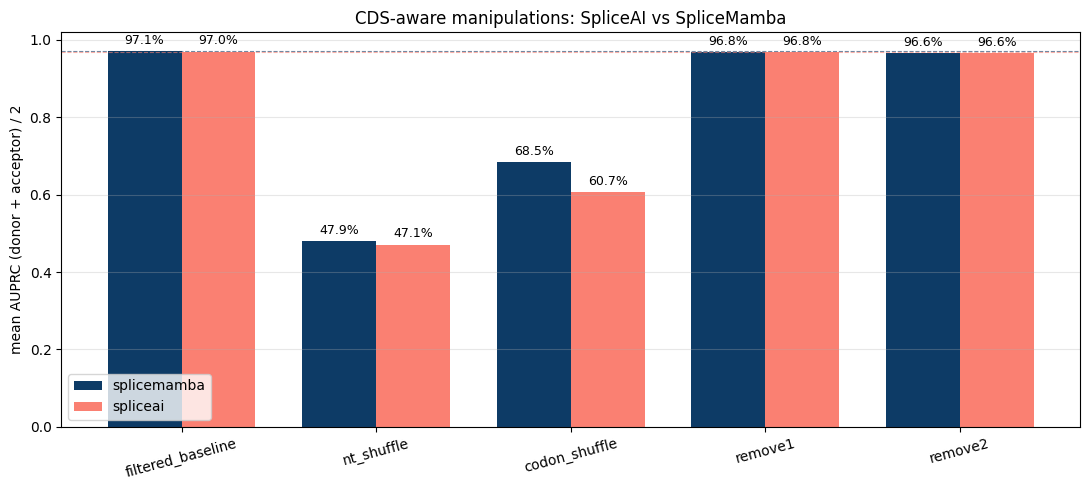

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(MODES))
width = 0.38
model_colour = {'splicemamba': '#0d3b66', 'spliceai': '#fa8072'}

for i, model in enumerate(MODELS):
    vals = [RESULTS.get((model, k), {}).get('auprc', {}).get('auprc_mean') if RESULTS.get((model, k)) else np.nan for k in MODES]
    
    # Assign the bar plot to a variable so we can label it
    bars = ax.bar(x + (i - 0.5) * width, vals, width=width, label=model, color=model_colour[model])
    
    # Create custom string labels, formatting as percentages (skipping NaNs)
    labels = [f"{v*100:.1f}%" if not np.isnan(v) else "" for v in vals]
    
    # Add the labels to the top of the bars
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
    
    base = RESULTS.get((model, 'filtered_baseline'), {})
    if base and base.get('auprc'):
        ax.axhline(base['auprc']['auprc_mean'], ls='--', lw=0.8, color=model_colour[model], alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(MODES, rotation=15)
ax.set_ylabel('mean AUPRC (donor + acceptor) / 2')
ax.set_title('CDS-aware manipulations: SpliceAI vs SpliceMamba')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Δ AUPRC vs the filtered baseline

Same data, expressed as the *drop* in AUPRC versus each model's own baseline. Direct measure of how much each manipulation hurts each model.

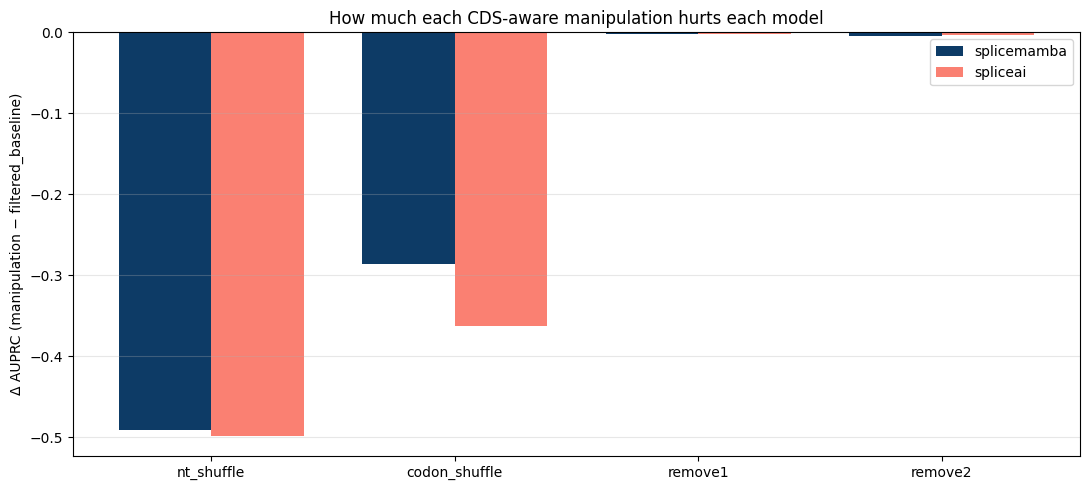

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
manip = [m for m in MODES if m != 'filtered_baseline']
x = np.arange(len(manip))
for i, model in enumerate(MODELS):
    base = RESULTS.get((model, 'filtered_baseline'), {})
    if not base or not base.get('auprc'):
        continue
    base_v = base['auprc']['auprc_mean']
    vals = []
    for k in manip:
        m_ = RESULTS.get((model, k))
        if m_ and m_.get('auprc'):
            vals.append(m_['auprc']['auprc_mean'] - base_v)
        else:
            vals.append(np.nan)
    ax.bar(x + (i - 0.5) * width, vals, width=width, label=model, color=model_colour[model])
ax.axhline(0, color='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(manip)
ax.set_ylabel('Δ AUPRC (manipulation − filtered_baseline)')
ax.set_title('How much each CDS-aware manipulation hurts each model')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Per-class AUPRC — donor vs acceptor

Splits the headline metric to surface any asymmetry between donor and acceptor calls under each manipulation.

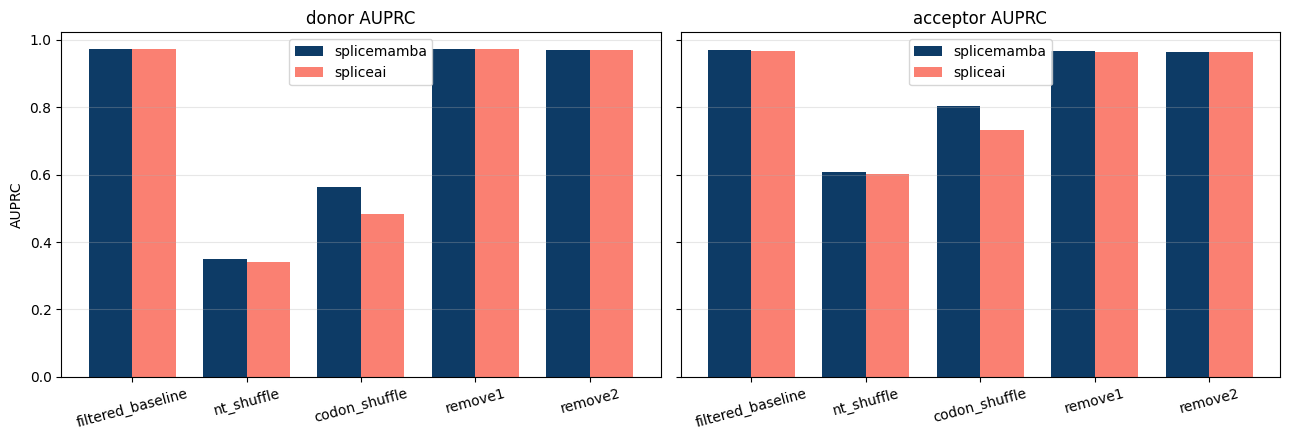

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, cls in zip(axes, ('donor', 'acceptor')):
    for i, model in enumerate(MODELS):
        vals = [RESULTS.get((model, k), {}).get('auprc', {}).get(f'auprc_{cls}') if RESULTS.get((model, k)) else np.nan for k in MODES]
        ax.bar(x_full := np.arange(len(MODES)) + (i - 0.5) * width, vals, width=width, label=model, color=model_colour[model])
    ax.set_xticks(np.arange(len(MODES)))
    ax.set_xticklabels(MODES, rotation=15)
    ax.set_title(f'{cls} AUPRC')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
axes[0].set_ylabel('AUPRC')
plt.tight_layout()
plt.show()

## Top-k accuracy across modes

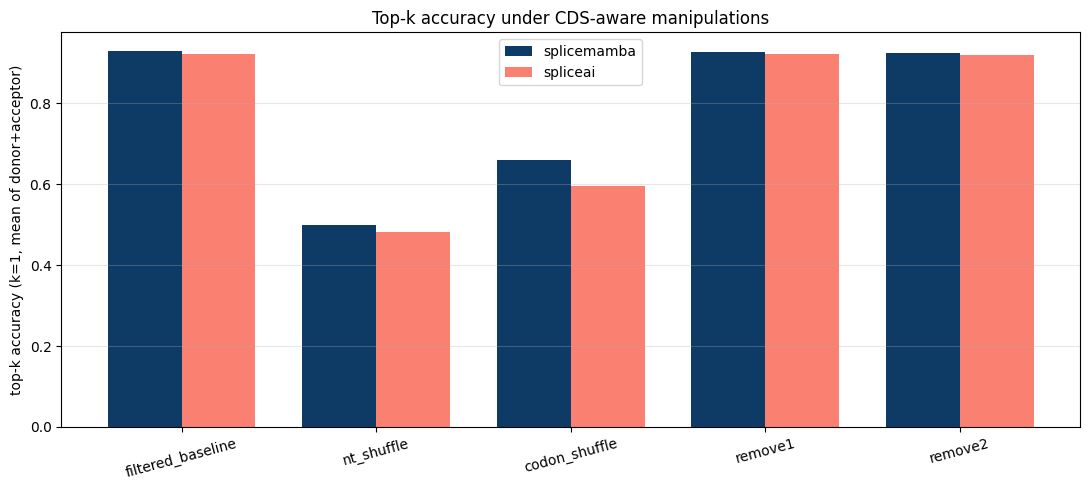

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, model in enumerate(MODELS):
    vals = [RESULTS.get((model, k), {}).get('topk', {}).get('topk_global_mean') if RESULTS.get((model, k)) else np.nan for k in MODES]
    ax.bar(np.arange(len(MODES)) + (i - 0.5) * width, vals, width=width, label=model, color=model_colour[model])
ax.set_xticks(np.arange(len(MODES)))
ax.set_xticklabels(MODES, rotation=15)
ax.set_ylabel('top-k accuracy (k=1, mean of donor+acceptor)')
ax.set_title('Top-k accuracy under CDS-aware manipulations')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## F1 @ optimal threshold (mean of donor + acceptor)

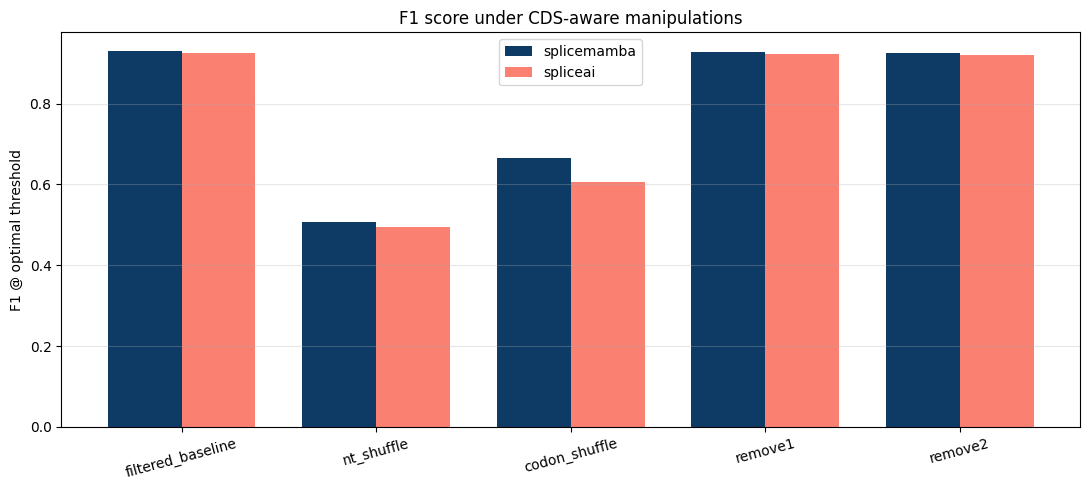

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, model in enumerate(MODELS):
    vals = []
    for k in MODES:
        m_ = RESULTS.get((model, k))
        if m_ and 'f1_optimal' in m_:
            vals.append((m_['f1_optimal']['f1_donor_best'] + m_['f1_optimal']['f1_acceptor_best']) / 2)
        else:
            vals.append(np.nan)
    ax.bar(np.arange(len(MODES)) + (i - 0.5) * width, vals, width=width, label=model, color=model_colour[model])
ax.set_xticks(np.arange(len(MODES)))
ax.set_xticklabels(MODES, rotation=15)
ax.set_ylabel('F1 @ optimal threshold')
ax.set_title('F1 score under CDS-aware manipulations')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Positional accuracy: peak detection within ±1 bp of the true junction

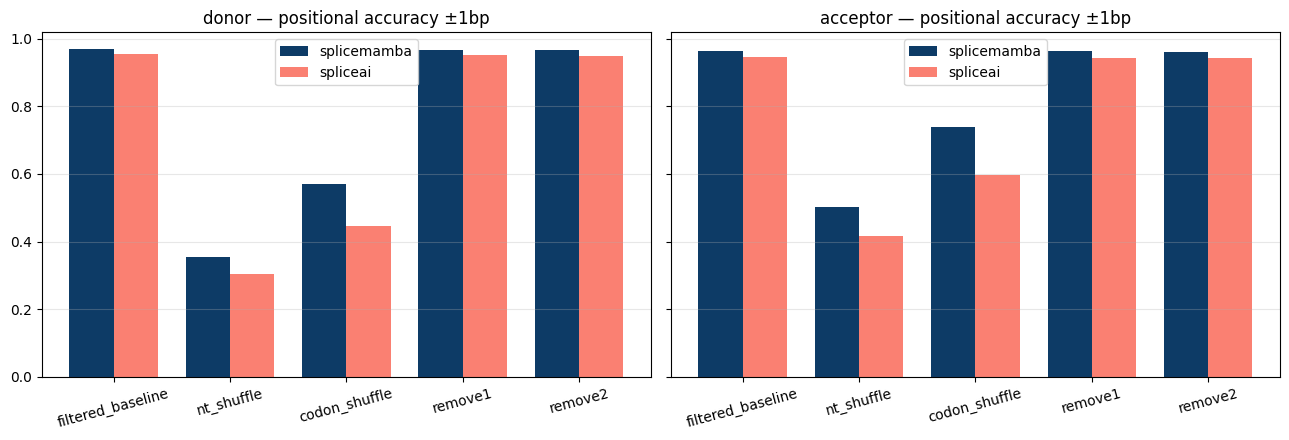

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, cls in zip(axes, ('donor', 'acceptor')):
    for i, model in enumerate(MODELS):
        vals = []
        for k in MODES:
            m_ = RESULTS.get((model, k))
            if m_ and 'positional' in m_:
                vals.append(m_['positional'].get(f'positional_{cls}_within_1bp'))
            else:
                vals.append(np.nan)
        ax.bar(np.arange(len(MODES)) + (i - 0.5) * width, vals, width=width, label=model, color=model_colour[model])
    ax.set_xticks(np.arange(len(MODES)))
    ax.set_xticklabels(MODES, rotation=15)
    ax.set_title(f'{cls} — positional accuracy ±1bp')
    ax.grid(axis='y', alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

## Heatmap of all metrics × all conditions × both models

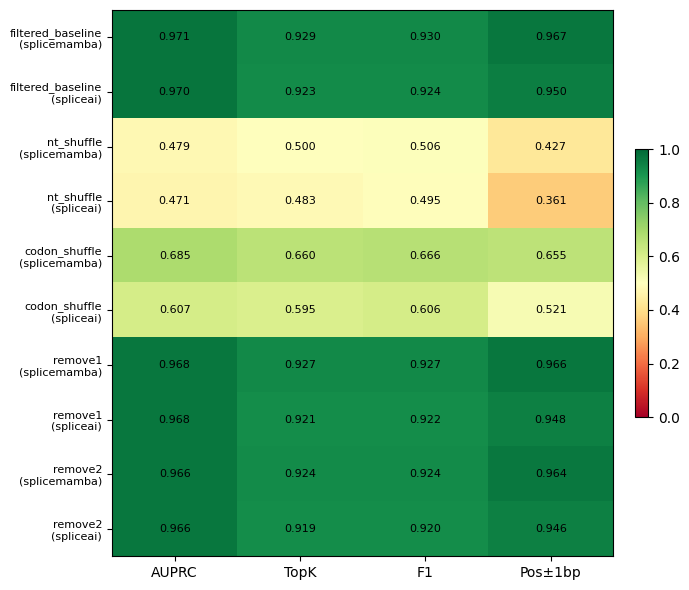

In [10]:
headline = []
for mode in MODES:
    for model in MODELS:
        m_ = RESULTS.get((model, mode))
        if not m_: continue
        headline.append({
            'condition': f'{mode}\n({model})',
            'AUPRC': m_['auprc']['auprc_mean'],
            'TopK': m_['topk']['topk_global_mean'],
            'F1': (m_['f1_optimal']['f1_donor_best'] + m_['f1_optimal']['f1_acceptor_best']) / 2,
            'Pos±1bp': (m_['positional']['positional_donor_within_1bp']
                        + m_['positional']['positional_acceptor_within_1bp']) / 2,
        })
if headline:
    df_h = pd.DataFrame(headline).set_index('condition')
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(df_h) + 1))
    im = ax.imshow(df_h.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_yticks(range(len(df_h))); ax.set_yticklabels(df_h.index, fontsize=8)
    ax.set_xticks(range(len(df_h.columns))); ax.set_xticklabels(df_h.columns)
    for i in range(len(df_h)):
        for j in range(len(df_h.columns)):
            v = df_h.values[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', color='black', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
    plt.tight_layout()
    plt.show()

## Deletion-position correlation (remove1 / remove2)

Reads each remove-mode manifest and inspects the per-gene deletion fractional position within its CDS. If the model relies on *where* in the CDS a base is (e.g. start codon vs stop codon), the histogram of `frac_in_cds` should reveal where deletions cluster.

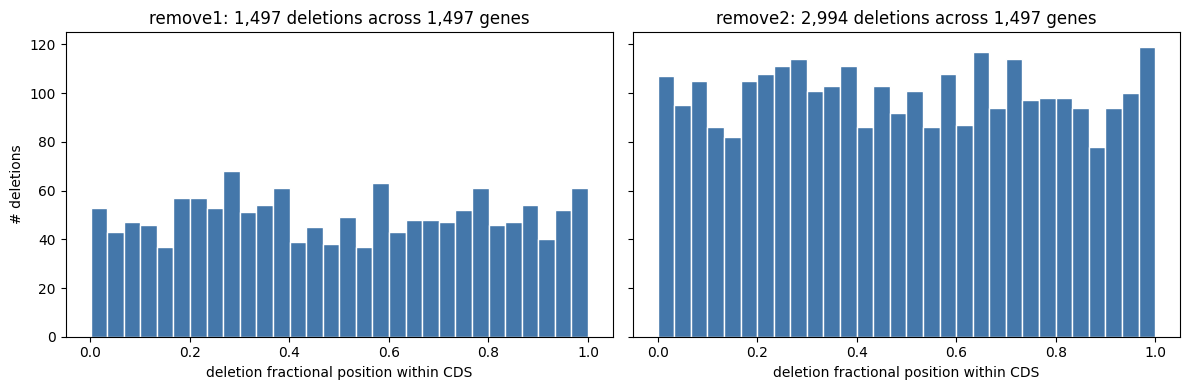

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, mode in zip(axes, ('remove1', 'remove2')):
    p = REPO_ROOT / f'datafile_test_cds_{mode}.h5.manifest.json'
    if not p.exists():
        ax.set_title(f'{mode} — manifest not found'); continue
    m = json.loads(p.read_text())
    fracs = [d['frac_in_cds'] for g in m['genes'] for d in g['deletions']]
    ax.hist(fracs, bins=30, color='#4477aa', edgecolor='white')
    ax.set_xlabel('deletion fractional position within CDS')
    ax.set_title(f'{mode}: {len(fracs):,} deletions across {len(m["genes"]):,} genes')
axes[0].set_ylabel('# deletions')
plt.tight_layout()
plt.show()

## Stratified by intron length

Splice-site recall by intron-length bucket — does either model degrade more on certain bucket sizes under each manipulation?

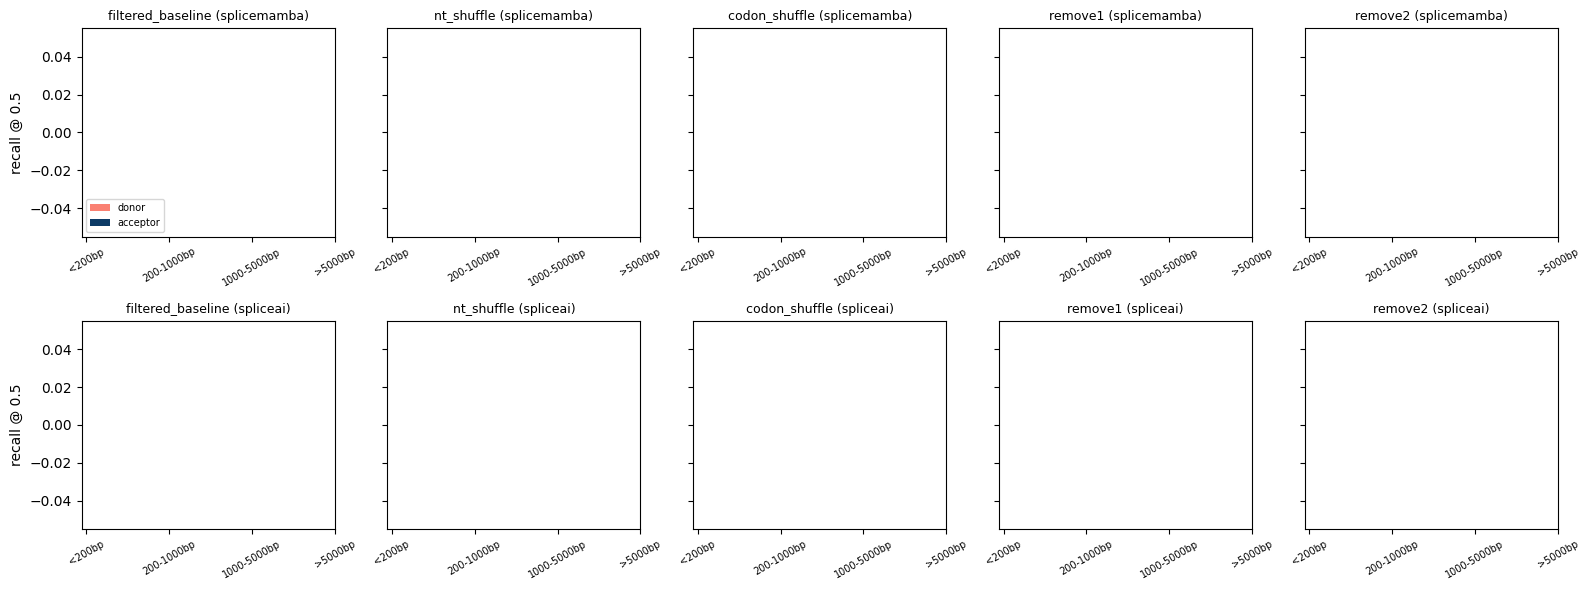

In [12]:
buckets = ['<200bp', '200-1000bp', '1000-5000bp', '>5000bp']
fig, axes = plt.subplots(2, len(MODES), figsize=(3 * len(MODES) + 1, 6), sharey=True)
for col, mode in enumerate(MODES):
    for row, model in enumerate(MODELS):
        ax = axes[row, col]
        m_ = RESULTS.get((model, mode))
        if not m_ or 'stratified_by_intron_length' not in m_:
            ax.set_title(f'{mode} ({model}) — n/a'); ax.set_axis_off(); continue
        s = m_['stratified_by_intron_length']
        # entries keyed by bucket and class
        donor_recall = [s.get(b, {}).get('donor', {}).get('recall_at_0.5', np.nan) for b in buckets]
        accept_recall = [s.get(b, {}).get('acceptor', {}).get('recall_at_0.5', np.nan) for b in buckets]
        x_ = np.arange(len(buckets))
        ax.bar(x_ - 0.2, donor_recall, width=0.4, label='donor', color='#fa8072')
        ax.bar(x_ + 0.2, accept_recall, width=0.4, label='acceptor', color='#0d3b66')
        ax.set_xticks(x_); ax.set_xticklabels(buckets, rotation=30, fontsize=7)
        ax.set_title(f'{mode} ({model})', fontsize=9)
        if col == 0: ax.set_ylabel('recall @ 0.5')
        if col == 0 and row == 0: ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Summary CSV (export)

Wide table for sharing / further analysis.

In [13]:
rows = []
for mode in MODES:
    for model in MODELS:
        m_ = RESULTS.get((model, mode))
        if not m_: continue
        rows.append({
            'model': model,
            'manipulation': mode,
            'auprc_mean': m_['auprc']['auprc_mean'],
            'auprc_donor': m_['auprc']['auprc_donor'],
            'auprc_acceptor': m_['auprc']['auprc_acceptor'],
            'topk_global_mean': m_['topk']['topk_global_mean'],
            'f1_donor_best': m_['f1_optimal']['f1_donor_best'],
            'f1_acceptor_best': m_['f1_optimal']['f1_acceptor_best'],
            'positional_donor_within_1bp': m_['positional']['positional_donor_within_1bp'],
            'positional_acceptor_within_1bp': m_['positional']['positional_acceptor_within_1bp'],
        })
df_summary = pd.DataFrame(rows)
out_csv = REPO_ROOT / 'evaluation' / 'results' / 'cds_summary.csv'
df_summary.to_csv(out_csv, index=False)
print(f'Wrote {out_csv}')
df_summary

Wrote /mnt/lareaulab/mparsa/splicing/evaluation/results/cds_summary.csv


,model,manipulation,auprc_mean,auprc_donor,auprc_acceptor,topk_global_mean,f1_donor_best,f1_acceptor_best,positional_donor_within_1bp,positional_acceptor_within_1bp
0,splicemamba,filtered_baseline,0.970685,0.973147,0.968223,0.929368,0.932176,0.927122,0.970297,0.964606
1,spliceai,filtered_baseline,0.969523,0.972137,0.966910,0.923326,0.927861,0.919685,0.953840,0.945845
2,splicemamba,nt_shuffle,0.479219,0.350087,0.608351,0.500468,0.414737,0.597562,0.353373,0.501214
3,spliceai,nt_shuffle,0.470990,0.341715,0.600264,0.483083,0.400337,0.588879,0.304031,0.416979
4,splicemamba,codon_shuffle,0.684664,0.564565,0.804763,0.659663,0.575298,0.756360,0.570236,0.739616
5,spliceai,codon_shuffle,0.607235,0.482210,0.732260,0.595463,0.514349,0.698349,0.445218,0.596454
6,splicemamba,remove1,0.968402,0.971788,0.965016,0.926873,0.930347,0.924345,0.968036,0.962969
7,spliceai,remove1,0.967667,0.971172,0.964162,0.921221,0.926051,0.917232,0.952281,0.944353
8,splicemamba,remove2,0.966485,0.970103,0.962866,0.923988,0.927084,0.921408,0.966243,0.961487
9,spliceai,remove2,0.966114,0.969851,0.962377,0.919155,0.924011,0.915464,0.949162,0.941943
